# Threshold Selection and Probability Calibration

This notebook is executable from the chapter directory.

## Learning goals

Fit a calibrated classifier, select a threshold on validation data using an expected-cost policy, freeze the threshold, and inspect reliability on the test period.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

REPO = Path.cwd().parents[1]
sys.path.insert(0, str(REPO / "src"))

from ml_foundations.calibration import expected_calibration_error
from ml_foundations.data import FEATURE_COLUMNS, temporal_split
from ml_foundations.metrics import threshold_sweep

ASSETS = Path.cwd() / "assets"
ASSETS.mkdir(exist_ok=True)
data = pd.read_csv(REPO / "data/incident_priority_synthetic.csv", parse_dates=["timestamp"])
train, validation, test = temporal_split(data)

## Fit raw and cross-validated calibrated models

The calibration folds are created inside the training period. Validation remains available for threshold selection.

In [2]:
base_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=3000, C=0.5),
)
base_model.fit(train[FEATURE_COLUMNS], train["is_p1"])

calibrated_model = CalibratedClassifierCV(
    estimator=make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=3000, C=0.5),
    ),
    method="sigmoid",
    cv=5,
)
calibrated_model.fit(train[FEATURE_COLUMNS], train["is_p1"])

p_val_raw = base_model.predict_proba(validation[FEATURE_COLUMNS])[:, 1]
p_val_cal = calibrated_model.predict_proba(validation[FEATURE_COLUMNS])[:, 1]

print("Validation raw log-loss:", round(log_loss(validation["is_p1"], p_val_raw), 5))
print("Validation calibrated log-loss:", round(log_loss(validation["is_p1"], p_val_cal), 5))
print("Validation raw Brier:", round(brier_score_loss(validation["is_p1"], p_val_raw), 5))
print("Validation calibrated Brier:", round(brier_score_loss(validation["is_p1"], p_val_cal), 5))

Validation raw log-loss: 0.49077
Validation calibrated log-loss: 0.108
Validation raw Brier: 0.16393
Validation calibrated Brier: 0.02493


## Select threshold on validation data

This teaching cost model uses 1 unit for a false positive and 25 units for a false negative. We also require recall of at least 0.85 when feasible.

In [3]:
sweep = pd.DataFrame(
    threshold_sweep(
        validation["is_p1"].to_numpy(),
        p_val_cal,
        false_positive_cost=1.0,
        false_negative_cost=25.0,
    )
)
feasible = sweep[sweep["recall"] >= 0.85]
selected = (feasible if len(feasible) else sweep).sort_values(["cost", "threshold"]).iloc[0]
selected_threshold = float(selected["threshold"])

print("Selected validation threshold:", selected_threshold)
print(selected[["cost", "precision", "recall", "fp", "fn"]])

Selected validation threshold: 0.01
cost         237.000
precision      0.052
recall         1.000
fp           237.000
fn             0.000
Name: 0, dtype: float64


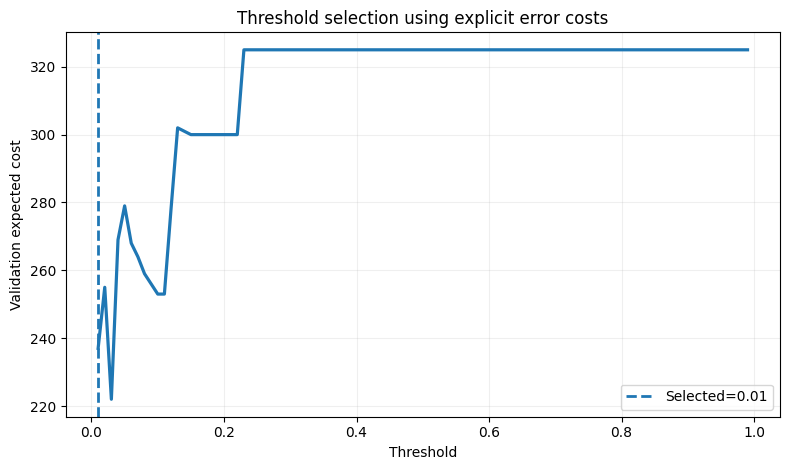

In [4]:
plt.figure(figsize=(8, 4.8))
plt.plot(sweep["threshold"], sweep["cost"], linewidth=2.3)
plt.axvline(selected_threshold, linestyle="--", linewidth=2, label=f"Selected={selected_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Validation expected cost")
plt.title("Threshold selection using explicit error costs")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS / "threshold_cost_curve.png", dpi=160)
plt.show()

## Freeze policy and evaluate probability quality on test data

In [5]:
p_test_raw = base_model.predict_proba(test[FEATURE_COLUMNS])[:, 1]
p_test_cal = calibrated_model.predict_proba(test[FEATURE_COLUMNS])[:, 1]

print("Test raw Brier:", round(brier_score_loss(test["is_p1"], p_test_raw), 5))
print("Test calibrated Brier:", round(brier_score_loss(test["is_p1"], p_test_cal), 5))
print("Test raw ECE:", round(expected_calibration_error(test["is_p1"], p_test_raw), 5))
print("Test calibrated ECE:", round(expected_calibration_error(test["is_p1"], p_test_cal), 5))

Test raw Brier: 0.22344
Test calibrated Brier: 0.02346
Test raw ECE: 0.36083
Test calibrated ECE: 0.0019


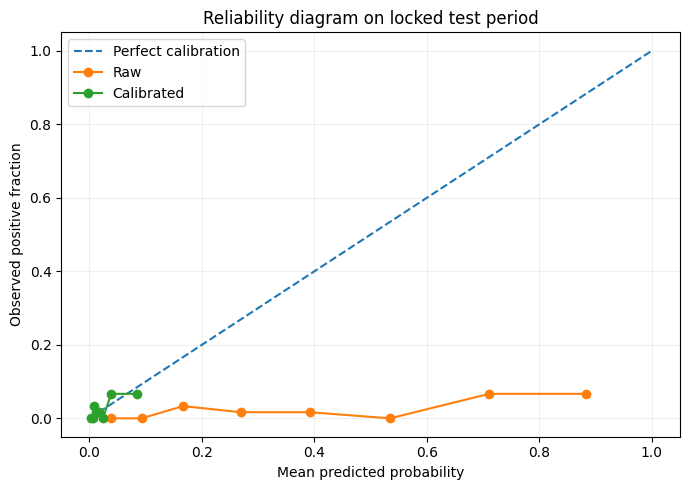

In [6]:
raw_observed, raw_predicted = calibration_curve(test["is_p1"], p_test_raw, n_bins=8, strategy="quantile")
cal_observed, cal_predicted = calibration_curve(test["is_p1"], p_test_cal, n_bins=8, strategy="quantile")

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(raw_predicted, raw_observed, marker="o", label="Raw")
plt.plot(cal_predicted, cal_observed, marker="o", label="Calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive fraction")
plt.title("Reliability diagram on locked test period")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS / "reliability_diagram.png", dpi=160)
plt.show()

## Operational scorecard at the frozen threshold

In [7]:
test_row = pd.DataFrame(
    threshold_sweep(
        test["is_p1"].to_numpy(),
        p_test_cal,
        thresholds=np.array([selected_threshold]),
        false_positive_cost=1.0,
        false_negative_cost=25.0,
    )
)
test_row[["threshold", "precision", "recall", "specificity", "f1", "fp", "fn", "cost"]]

,threshold,precision,recall,specificity,f1,fp,fn,cost
0,0.01,0.033898,0.833333,0.391026,0.065147,285.0,2.0,335.0


## Interview reflection

Explain why calibration can improve Brier score without improving ROC-AUC, and why threshold selection must be repeated when cost, capacity, or prevalence changes.